# Embedding with htsne and humap

How to call mixle's model-based embeddings. `htsne` and `humap` fit a mixture model to heterogeneous data, turn the posteriors into pairwise affinities, and lay them out in 2-D with t-SNE / UMAP respectively. This is the syntax tutorial; for the affinity theory and failure modes see the data-science notebook model_based_embeddings, and for a real case study see malware_certificate_embedding.


In [1]:
import io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from mixle.stats import (GaussianDistribution, CategoricalDistribution, PoissonDistribution,
                        BernoulliSetDistribution, CompositeDistribution, OptionalDistribution)
from mixle.utils.hvis import htsne, humap

# a labelled mixture of HETEROGENEOUS records: a real value, a category,
# a set of tags, and a sometimes-missing count -- four different field types
TAGS = ['a', 'b', 'c', 'd']
def make_record_groups(seed=1, per=40):
    rng = np.random.RandomState(seed)
    comps = [CompositeDistribution((GaussianDistribution(3.0 * k, 1.0),
                                    CategoricalDistribution({'x': [0.8, 0.34, 0.1][k], 'y': [0.1, 0.33, 0.1][k], 'z': [0.1, 0.33, 0.8][k]}),
                                    BernoulliSetDistribution({t: (0.8 if (i % 4) == k else 0.15) for i, t in enumerate(TAGS)}),
                                    OptionalDistribution(PoissonDistribution(2.0 + 3 * k), p=0.2)))
             for k in range(3)]
    data, labels = [], []
    for k, comp in enumerate(comps):
        s = comp.sampler(seed=rng.randint(2**31))
        for _ in range(per):
            data.append(s.sample()); labels.append(k)
    return data, np.asarray(labels)

data, labels = make_record_groups()
print('%d records, each = (real, category, tag-set, maybe-missing count); e.g. %r' % (len(data), data[0]))

120 records, each = (real, category, tag-set, maybe-missing count); e.g. (0.9255484720974448, 'x', ['a'], 1)


## `htsne(data)` - the one-call embedding

Pass the raw heterogeneous records. `htsne` fits the model, computes affinities, and returns an `(n, 2)` array. `out=` captures the fitting log; `seed=` and `perplexity=` control the t-SNE layout.


embedding shape: (120, 2)


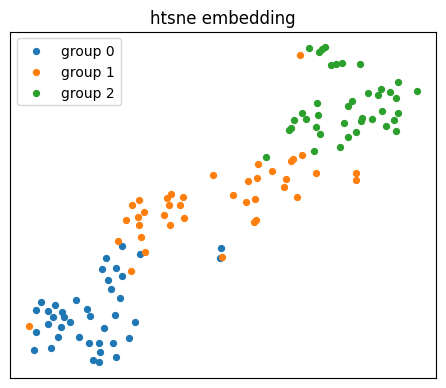

In [2]:
emb = htsne(data, seed=1, perplexity=20, out=io.StringIO())
print('embedding shape:', emb.shape)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for k in range(3):
    m = labels == k
    ax.scatter(emb[m, 0], emb[m, 1], s=18, label='group %d' % k)
ax.set_title('htsne embedding'); ax.set_xticks([]); ax.set_yticks([]); ax.legend()
plt.show()

## `humap(data)` - the UMAP layout

Same affinities, different layout engine. Takes `n_neighbors=` instead of `perplexity=`.


In [3]:
um = humap(data, seed=1, n_neighbors=15, out=io.StringIO())
print('humap shape:', um.shape)

humap shape: (120, 2)


## Choosing the affinity

The embedding is only as good as the pairwise affinity it lays out, and `htsne` offers several ways to turn the fitted mixture's per-point posteriors into affinities:

| `affinity=` | what two points are "close" means |
|---|---|
| `'auto'` (default) | the per-field, evidence-capped posterior overlap - robust across heterogeneous fields |
| `'bhattacharyya'` | distributional overlap of the two points' component-posteriors (Bhattacharyya coefficient) |
| `'coassign'` | probability the two points are assigned to the same mixture component |
| `'fisher'` | distance in the model's Fisher information metric (local curvature of the likelihood) |

They can produce visibly different maps from the same fitted model. Below, the same heterogeneous records under each affinity - colour is the true group.


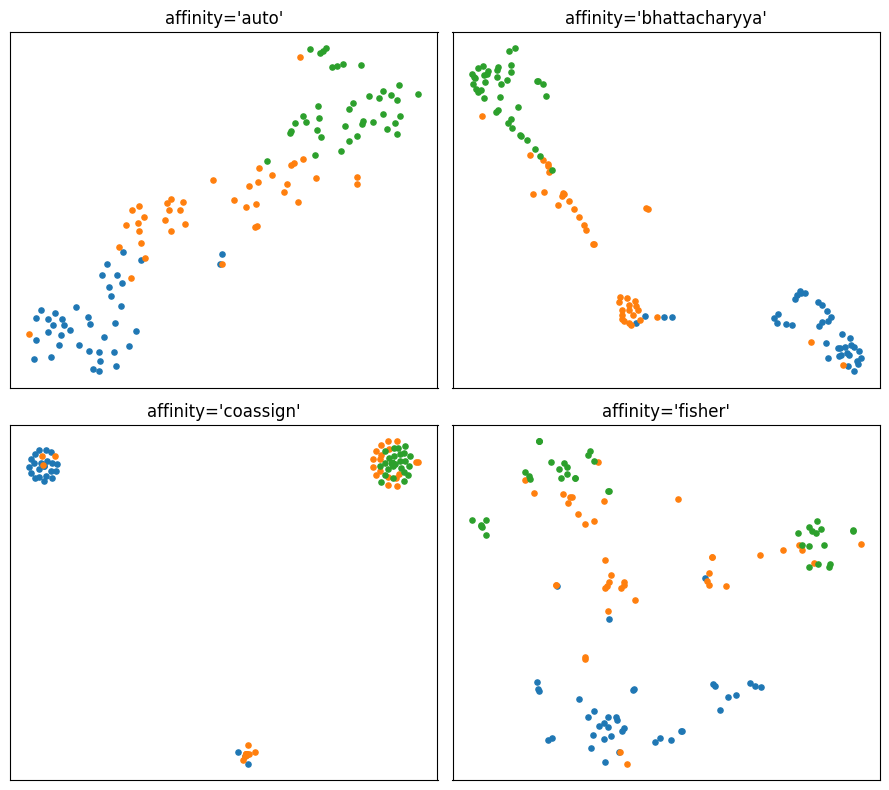

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, aff in zip(axes.ravel(), ['auto', 'bhattacharyya', 'coassign', 'fisher']):
    Y = htsne(data, seed=1, perplexity=20, affinity=aff, out=io.StringIO())
    for k in range(3):
        m = labels == k
        ax.scatter(Y[m, 0], Y[m, 1], s=14)
    ax.set_title("affinity='%s'" % aff); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

### Reusing a fitted model

`htsne` fits a mixture internally, but you can supply your own with `mix_model=` - useful to embed several datasets in a comparable space, or to reuse an expensive fit. Pass any fitted `mixle.stats` mixture; the affinities are computed from its posteriors.


In [5]:
from mixle.stats import (MixtureEstimator, CompositeEstimator, GaussianEstimator,
                        CategoricalEstimator, BernoulliSetEstimator, OptionalEstimator, PoissonEstimator)
from mixle.inference.estimation import optimize
comp = CompositeEstimator((GaussianEstimator(), CategoricalEstimator(),
                           BernoulliSetEstimator(), OptionalEstimator(PoissonEstimator())))
mix = optimize(data, MixtureEstimator([comp] * 3), max_its=30, rng=np.random.RandomState(0), out=io.StringIO())
Y = htsne(data, seed=1, perplexity=20, mix_model=mix, out=io.StringIO())
print('embedded with a supplied 3-component mixture ->', Y.shape)

embedded with a supplied 3-component mixture -> (120, 2)
